In the previous lesson we identified stars with the proper motion we expect for GD-1

Now we'll do the same selection in an ADQL query, which will make it possible to work with a larger region of the sky and still download less data

In [2]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import ConvexHull
import astropy.units as u
import GD1Koposov10
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia
import reflex_correct

# Reloading the data

Reload the data from the hdf file created in the previous lesson

In [3]:
filename = "gd1_data.hdf"
centerline_df = pd.read_hdf(filename, "centerline_df")
selected_df = pd.read_hdf(filename, "selected_df")

At this point we have downloaded data for a farily large number of stars (over 100,000) and selected a relatively small number (around 1000)

It would be more efficient to use an ADQL query to select only the stars we need. This method also allows us to download data covering a larger region of the sky 

The selection we did was based on proper motion in the GD-1 frame. In order to do the same selection in ADQL we have to work with proper motion in ICRS 

In [4]:
# The rectangle we selected based on proper motion in the 
# GD-1 frame 
pm1_min = -8.9
pm1_max = -6.9
pm2_min = -2.2
pm2_max =  1.0

In [5]:
def make_rectangle(x1,x2,y1,y2):
    """ Return the corners of a rectangle"""
    xs = [x1, x1, x2, x2, x1]
    ys = [y1, y2, y2, y1, y1]
    return xs, ys

In [6]:
pm1_rect, pm2_rect = make_rectangle(
    pm1_min, pm1_max, pm2_min, pm2_max
)

In [8]:
def plot_proper_motion(df):
    """Plot proper motion

    df: Dataframe with 'pm_phi1' and 'pm_phi2'
    """

    x = df["pm_phi1"]
    y = df["pm_phi2"]
    plt.plot(x, y, "ko", markersize=0.3, alpha=0.3)
    
    plt.xlabel('Proper motion phi1 (GD1 frame)')
    plt.ylabel('Proper motion phi2 (GD1 frame)')

    plt.xlim(-12, 8)
    plt.ylim(-10, 10)

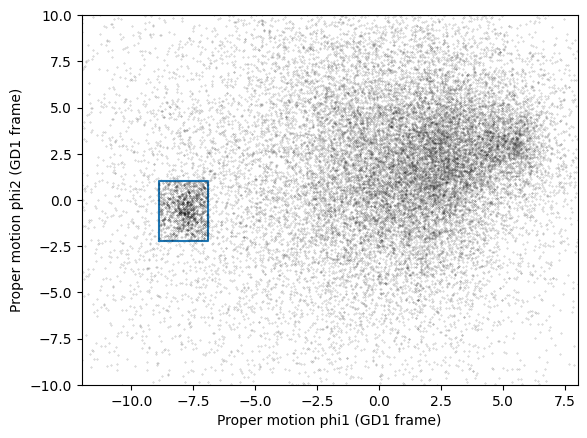

In [13]:
plot_proper_motion(centerline_df)

plt.plot(pm1_rect, pm2_rect)

x = selected_df["pm_phi1"]
y = selected_df["pm_phi2"]
#plt.plot(x, y, "ko", markersize=0.3, alpha=0.3)
plot_proper_motion(selected_df)